# Figure: Intermediary Matching

This notebook generates figures from **Experiment 4** results.

**Inputs**: `../data/results_4/` (JSON files), `../data/instances/2020-08-27.yaml`

**Outputs**:
- `../figures/matched_heatplot.pdf` — Heatmap of matched intermediaries by cost and deviation potential
- `../figures/intermediary_profit.pdf` — Intermediary profit visualization

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from copy import deepcopy


from farmers_intermediaries import Instance
from road_graphs import RoadGraph
import pickle
import pandas as pd
import pricing
from pricing import Optimizer
from datetime import datetime, timedelta
import numpy as np
from instance_generator import InstanceGenerator

json_files = {}
directory = "../data/results_sc"

for filename in os.listdir(directory):
    if filename.endswith(".json"):
        filepath = os.path.join(directory, filename)
        with open(filepath, 'r') as file:
            json_files[filename] = json.load(file)

In [3]:
summ_dict = []
farmer_dict = []
maximum = -np.inf
minimum = np.inf
for name, json_file in json_files.items():
    for grid_index, result in enumerate(json_file):
        for int_prioritized in result["cost"]:
            matched = int_prioritized in result["summary_vanilla"]["max_int_welf_sol"]["matched_set"]
            summ_dict.append({
                "epsilon": result["epsilon"][int_prioritized],
                "cost": result["cost"][int_prioritized],
                "status-quo": result["summary_vanilla"]["instance"]["status_quo_quantities"][int_prioritized],
                "power": result["epsilon"][int_prioritized]+result["summary_vanilla"]["instance"]["status_quo_quantities"][int_prioritized],
                "instance_id": result["instance_id"],
                "int_prioritized": int_prioritized,
                "matched": float(matched),
                "profit_max": result["summary_vanilla"]["max_int_welf_sol"]["intermediary_profits"][int_prioritized]/ 14500.0,
                "profit_min": result["summary_vanilla"]["min_int_welf_sol"]["intermediary_profits"][int_prioritized]/ 14500.0,
            })            

df = pd.DataFrame(summ_dict)
df = df.query("power <=12")
df["profit_max_after_payment"] = df["profit_max"] + df["cost"]
df["fixed_cost"] = df["cost"] + 800000
df["fixed_cost"] = df["fixed_cost"]/14500.0

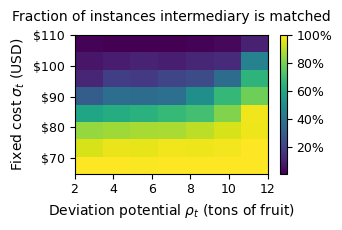

In [4]:
from matplotlib.ticker import FuncFormatter

# Define a formatter function for the y-axis
def currency_formatter(x, pos):
    return f'${x:.0f}'


import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

# Create bins for power and cost
power_bins = np.linspace(2, 12, 7)
cost_bins = np.linspace(65, 110, 7)

# Assign bin indices
df['power_bin'] = np.digitize(df['power'], power_bins) - 1
df['cost_bin'] = np.digitize(df['fixed_cost'], cost_bins) - 1

# Compute probability that matched = 1 in each (power, cost) bin
heatmap = df.groupby(['power_bin', 'cost_bin'])['matched'].mean().unstack() * 100  # Convert to percentage

# Plot heatmap
plt.figure(figsize=(3.5, 2.4))
plt.imshow(
    heatmap.T, origin='lower', aspect='auto',
    extent=[power_bins[0], power_bins[-1], cost_bins[0], cost_bins[-1]],
    cmap='viridis'
)
cbar = plt.colorbar()
# Format colorbar ticks as percentages
cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.xlabel(r'Deviation potential $\rho_t$ (tons of fruit)')
#plt.xticks(ticks=np.arange(len(power_bins)), labels=[f"{p:.1f}" for p in power_bins], rotation=45)
# Apply the formatter to the y-axis
plt.gca().yaxis.set_major_formatter(FuncFormatter(currency_formatter))
plt.ylabel(r'Fixed cost $\sigma_t$ (USD)')
plt.title(r'Fraction of instances intermediary is matched', pad=10)
plt.tight_layout()
plt.savefig("../figures/matched_heatplot.pdf", bbox_inches='tight')  # INFORMS-compliant
plt.show()


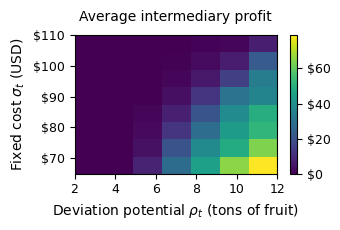

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



# Create bins for power and cost
power_bins = np.linspace(2, 12, 7)
cost_bins = np.linspace(65, 110, 7)

# Assign bin indices
df['power_bin'] = np.digitize(df['power'], power_bins) - 1
df['cost_bin'] = np.digitize(df['fixed_cost'], cost_bins) - 1

heatmap = df.groupby(['power_bin', 'cost_bin'])['profit_max'].mean().unstack()

# Plot heatmap
plt.figure(figsize=(3.5, 2.4))
plt.imshow(
    heatmap.T, origin='lower', aspect='auto',
    extent=[power_bins[0], power_bins[-1], cost_bins[0], cost_bins[-1]],
    cmap='viridis'
)

plt.gca().yaxis.set_major_formatter(FuncFormatter(currency_formatter))
plt.ylabel(r'Fixed cost $\sigma_t$ (USD)')
cbar = plt.colorbar(label='')
cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:.0f}'))

plt.xlabel(r'Deviation potential $\rho_t$ (tons of fruit)')
#plt.xticks(ticks=np.arange(len(power_bins)), labels=[f"{p:.1f}" for p in power_bins], rotation=45)
plt.gca().yaxis.set_major_formatter(FuncFormatter(currency_formatter))
plt.title(r"Average intermediary profit", pad=10)
plt.tight_layout()

plt.savefig("../figures/intermediary_profit.pdf", bbox_inches='tight')  # INFORMS-compliant
plt.show()